In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    precision_recall_curve, roc_curve, average_precision_score
)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

#df=pd.read_csv('/Users/mohammadhosein/Desktop/churn_project/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Phase 1: Business Understanding (already covered in previous response)

# Phase 2: Data Understanding & Phase 3: Data Preparation
# Handle missing values (including spaces in TotalCharges)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'], inplace=True)

# Separate features and target
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Define feature types
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
categorical_features = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                        'Contract', 'PaymentMethod']

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', RobustScaler())
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('label', LabelEncoder())
])

# For multi-category features, we'll one-hot encode in ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', 'passthrough', categorical_features),  # Will be handled separately
        ('binary', 'passthrough', binary_features)
    ])

# Phase 4: Modeling
# Define models with their respective preprocessing steps
# First, let's prepare the data properly

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X[categorical_features], drop_first=False)
X_binary = X[binary_features].apply(lambda col: col.map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}))
X_numeric_scaled = preprocessor.fit_transform(X[numeric_features])

# Combine all features
X_processed = np.hstack([X_numeric_scaled, X.binary.values, X_encoded.values])

# Train-test split (stratified to handle class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Model Definitions
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Phase 5: Hyperparameter Tuning
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.1, 0.01],
        'scale_pos_weight': [1, 3]  # Handle class imbalance
    }
}

# Fit models with hyperparameter tuning
best_models = {}
for name, model in models.items():
    print(f"\nTuning {name}...")
    search = GridSearchCV(model, param_grids[name], cv=3, scoring='recall', n_jobs=-1)
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    print(f"Best params for {name}: {search.best_params_}")

# Phase 6: Evaluation
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    
    # Metrics
    report = classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    
    return {
        'model_name': model_name,
        'classification_report': report,
        'auc_roc': auc_roc,
        'avg_precision': avg_precision,
        'confusion_matrix': cm,
        'roc_curve': (fpr, tpr),
        'pr_curve': (precision, recall)
    }

# Evaluate all models
results = {}
for name, model in best_models.items():
    results[name] = evaluate_model(model, X_test, y_test, name)

# Visualization of Results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# Plot ROC curves
for name, result in results.items():
    axes[0].plot(result['roc_curve'][0], result['roc_curve'][1], label=f"{name} (AUC = {result['auc_roc']:.2f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

# Plot Precision-Recall curves
for name, result in results.items():
    axes[1].plot(result['pr_curve'][1], result['pr_curve'][0], label=f"{name} (AP = {result['avg_precision']:.2f})")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

# Plot Confusion Matrices
for idx, (name, result) in enumerate(results.items()):
    if idx < 2:  # Only plot first two
        sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', ax=axes[2+idx], cmap='Blues')
        axes[2+idx].set_title(f'{name} Confusion Matrix')
        axes[2+idx].set_xlabel('Predicted')
        axes[2+idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Print detailed reports
for name, result in results.items():
    print(f"\n{name} Performance:")
    print("="*30)
    print(result['classification_report'])
    print(f"AUC-ROC: {result['auc_roc']:.3f}")
    print(f"Average Precision: {result['avg_precision']:.3f}")

f:\app space\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


ValueError: A given column is not a column of the dataframe

NaN count after preprocessing: 0
Training set size: 5634
Test set size: 1409

Tuning Logistic Regression...
Best params for Logistic Regression: {'C': 10, 'penalty': 'l1'}

Tuning Random Forest...
Best params for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

Tuning XGBoost...
Best params for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 3}


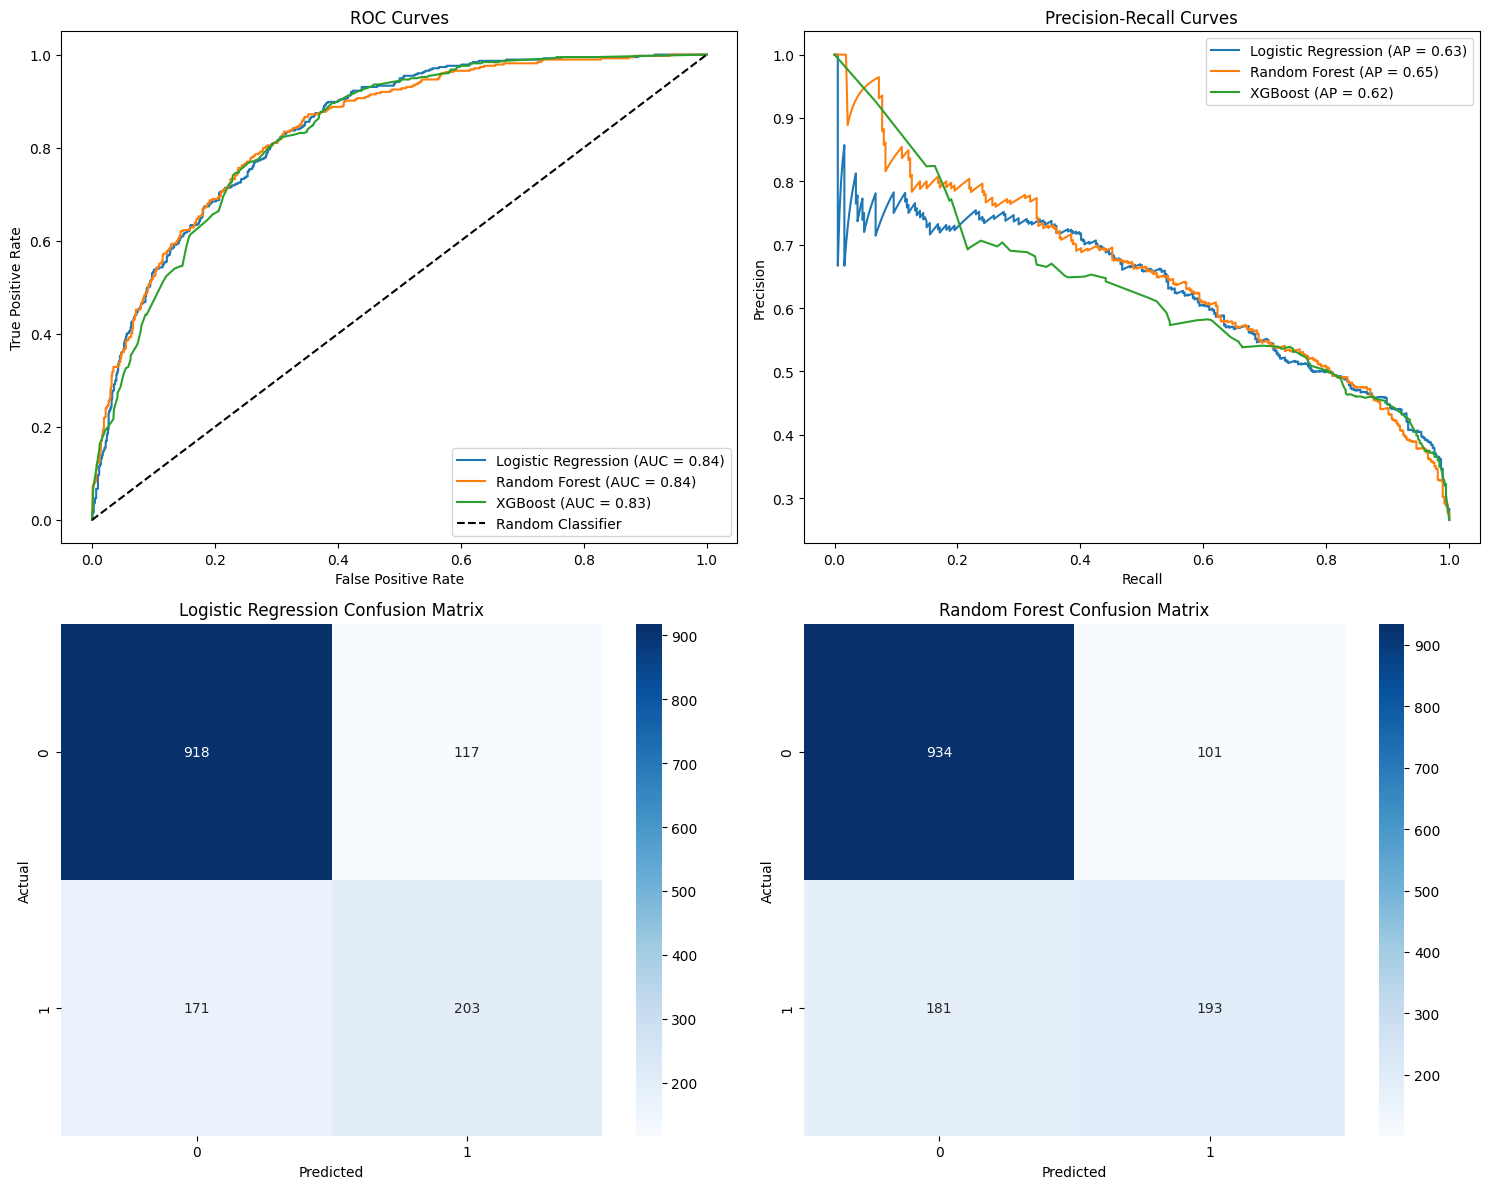


Logistic Regression Performance:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

AUC-ROC: 0.840
Average Precision: 0.628

Random Forest Performance:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

AUC-ROC: 0.838
Average Precision: 0.653

XGBoost Performance:
              precision    recall  f1-score   support

    No Churn       0.92      0.68      0.78      1035
       Churn       0.48      0.83      0.61       374

    accuracy      

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Handle missing values in TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'], inplace=True)

# Separate features and target
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Define feature types
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
binary_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
categorical_features = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('binary', binary_transformer, binary_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

# Check for NaN
print("NaN count after preprocessing:", np.isnan(X_processed).sum())

# Train-test split (stratified to handle class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Model Definitions
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='liblinear'),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Hyperparameter Tuning
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'penalty': ['l1', 'l2'],
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.1, 0.01],
        'scale_pos_weight': [1, 3]
    }
}

# Fit models with hyperparameter tuning
best_models = {}
for name, model in models.items():
    print(f"\nTuning {name}...")
    search = GridSearchCV(model, param_grids[name], cv=3, scoring='recall', n_jobs=-1)
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    print(f"Best params for {name}: {search.best_params_}")

# Evaluation
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    report = classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

    return {
        'model_name': model_name,
        'classification_report': report,
        'auc_roc': auc_roc,
        'avg_precision': avg_precision,
        'confusion_matrix': cm,
        'roc_curve': (fpr, tpr),
        'pr_curve': (precision, recall)
    }

# Evaluate all models
results = {}
for name, model in best_models.items():
    results[name] = evaluate_model(model, X_test, y_test, name)

# Visualization of Results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# Plot ROC curves
for name, result in results.items():
    axes[0].plot(result['roc_curve'][0], result['roc_curve'][1], label=f"{name} (AUC = {result['auc_roc']:.2f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

# Plot Precision-Recall curves
for name, result in results.items():
    axes[1].plot(result['pr_curve'][1], result['pr_curve'][0], label=f"{name} (AP = {result['avg_precision']:.2f})")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

# Plot Confusion Matrices
for idx, (name, result) in enumerate(results.items()):
    if idx < 2:
        sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', ax=axes[2+idx], cmap='Blues')
        axes[2+idx].set_title(f'{name} Confusion Matrix')
        axes[2+idx].set_xlabel('Predicted')
        axes[2+idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Print detailed reports
for name, result in results.items():
    print(f"\n{name} Performance:")
    print("="*30)
    print(result['classification_report'])
    print(f"AUC-ROC: {result['auc_roc']:.3f}")
    print(f"Average Precision: {result['avg_precision']:.3f}")

In [6]:
from sklearn.metrics import precision_recall_curve
y_probs = best_models['XGBoost'].predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
# Plot precision vs. recall and choose a threshold

In [7]:
print(precision, recall, thresholds)

[0.26543648 0.30541872 0.30718415 0.31       0.31025855 0.31578947
 0.31605777 0.31740614 0.32041344 0.32096635 0.32152118 0.32235702
 0.3226087  0.32345248 0.32373473 0.34680451 0.34713076 0.34745763
 0.34980989 0.35316699 0.35624395 0.35762877 0.35832522 0.3590998
 0.36157635 0.36229023 0.36264822 0.36300692 0.36336634 0.3640873
 0.36481113 0.365      0.36831483 0.36905966 0.3698075  0.37018256
 0.37055838 0.37093496 0.37029502 0.3706721  0.37104995 0.37142857
 0.37218814 0.37154555 0.37166324 0.37204522 0.37242798 0.37281153
 0.37319588 0.37396694 0.3747412  0.37409326 0.37448133 0.3748702
 0.37422037 0.37434828 0.37473904 0.37552301 0.37670514 0.38552916
 0.38636364 0.38695652 0.38779956 0.38907104 0.38949672 0.39077936
 0.39356984 0.39576366 0.39709172 0.39753639 0.39798206 0.39864865
 0.39909808 0.4        0.40227273 0.40273038 0.40410959 0.40435281
 0.40481651 0.40528129 0.40574713 0.42016807 0.42424242 0.42594859
 0.42699387 0.42751843 0.42786683 0.4289246  0.43396226 0.4390243

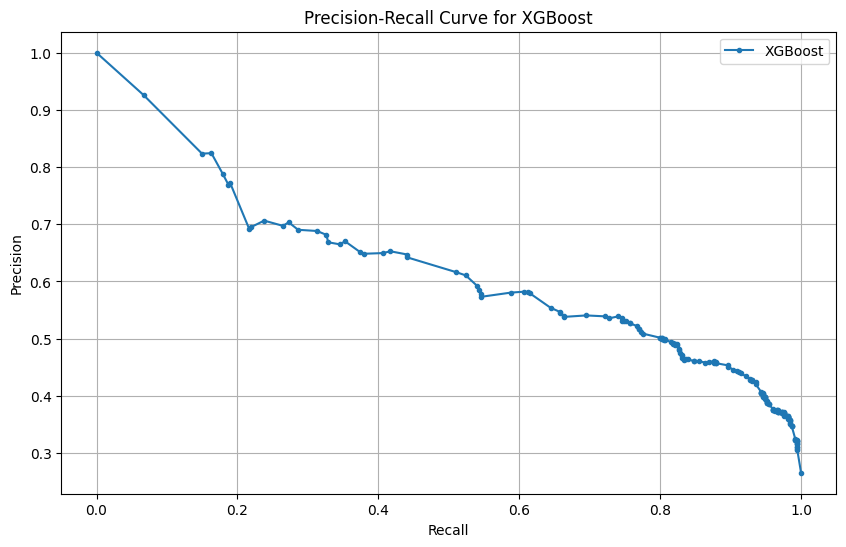

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.', label='XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for XGBoost')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
y_probs = best_models['XGBoost'].predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs >= 0.4).astype(int)  # Use your chosen threshold

# Evaluate with the new threshold
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.96      0.48      0.64      1035
       Churn       0.40      0.95      0.56       374

    accuracy                           0.60      1409
   macro avg       0.68      0.71      0.60      1409
weighted avg       0.81      0.60      0.62      1409



In [10]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"Best threshold: {best_threshold:.3f}, F1-score: {best_f1:.3f}")

Best threshold: 0.591, F1-score: 0.624



Logistic Regression
{'clf__C': 10, 'clf__penalty': 'l1'}
[[741 294]
 [ 82 292]]
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409


Random Forest
{'clf__max_depth': 10, 'clf__n_estimators': 200}
[[808 227]
 [103 271]]
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.77      1409


XGBoost
{'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200}
[[748 287]
 [ 70 304]]
              precision    recall  f1-score   support

           0   

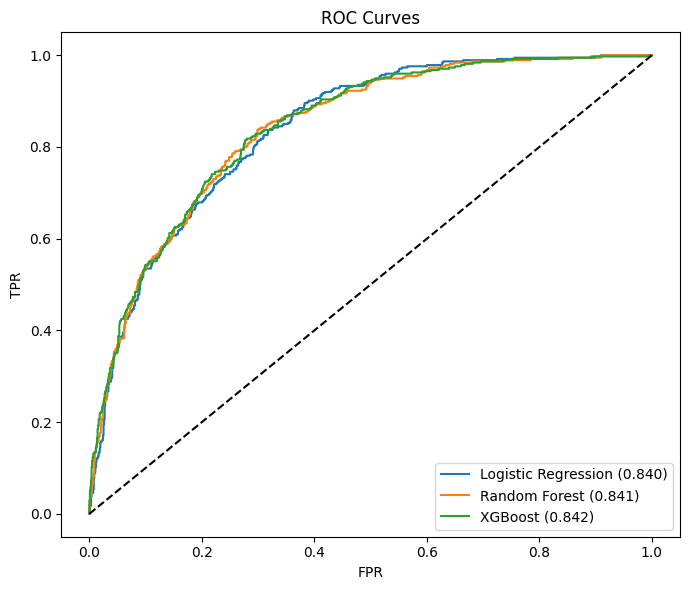

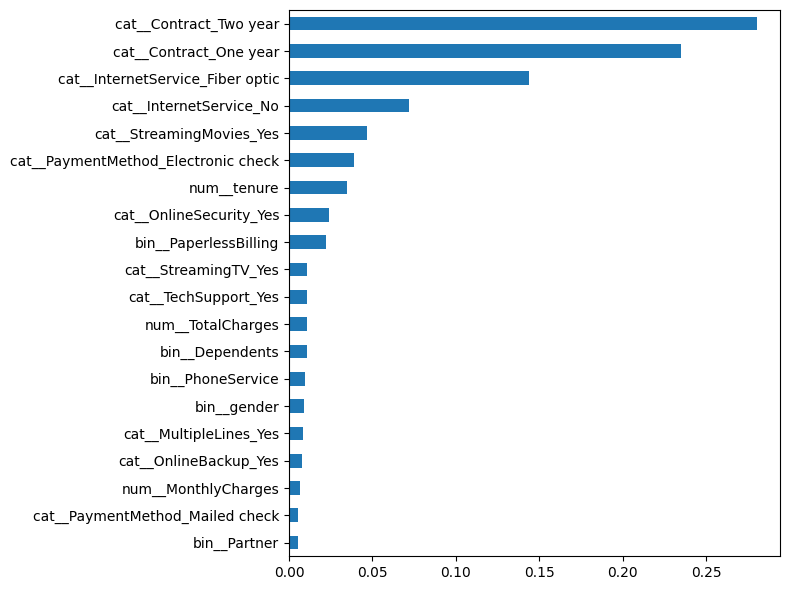

In [2]:
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     train_test_split, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"]*df["tenure"])

X = df.drop(columns=["customerID","Churn"])
y = df["Churn"].map({"No":0,"Yes":1})

num = ["tenure","MonthlyCharges","TotalCharges"]
binary = ["gender","Partner","Dependents","PhoneService","PaperlessBilling"]
cat = ["MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
       "DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
       "Contract","PaymentMethod"]

pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp",SimpleImputer(strategy="median")),
        ("scale",RobustScaler())
    ]), num),
    ("bin", Pipeline([
        ("imp",SimpleImputer(strategy="most_frequent")),
        ("enc",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
    ]), binary),
    ("cat", Pipeline([
        ("imp",SimpleImputer(strategy="most_frequent")),
        ("enc",OneHotEncoder(handle_unknown="ignore",drop="first"))
    ]), cat)
])

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=RANDOM_STATE)

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

neg=(y_train==0).sum(); pos=(y_train==1).sum()
spw=neg/pos

models={
"Logistic Regression":(
    LogisticRegression(max_iter=1000,solver="liblinear",class_weight="balanced"),
    {"clf__C":[0.1,1,10],"clf__penalty":["l1","l2"]}
),
"Random Forest":(
    RandomForestClassifier(random_state=RANDOM_STATE,class_weight="balanced"),
    {"clf__n_estimators":[200],"clf__max_depth":[None,10,20]}
)
}
if HAS_XGB:
    models["XGBoost"]=(
        XGBClassifier(random_state=RANDOM_STATE,eval_metric="logloss",
                      scale_pos_weight=spw),
        {"clf__n_estimators":[200],"clf__max_depth":[3,5],
         "clf__learning_rate":[0.05,0.1]}
    )

results=[]
best_model=None
best_auc=-1

plt.figure(figsize=(7,6))
for name,(est,param) in models.items():
    pipe=Pipeline([("prep",pre),("clf",est)])
    gs=GridSearchCV(pipe,param,cv=cv,scoring="roc_auc",n_jobs=-1)
    gs.fit(X_train,y_train)
    model=gs.best_estimator_
    prob=model.predict_proba(X_test)[:,1]
    pred=(prob>=0.5).astype(int)
    auc=roc_auc_score(y_test,prob)
    ap=average_precision_score(y_test,prob)
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred),
        "Recall":recall_score(y_test,pred),
        "F1":f1_score(y_test,pred),
        "ROC_AUC":auc,
        "PR_AUC":ap,
        "CV_AUC":cross_val_score(model,X,y,cv=cv,scoring="roc_auc").mean()
    })
    print(f"\n{name}")
    print(gs.best_params_)
    print(confusion_matrix(y_test,pred))
    print(classification_report(y_test,pred))
    fpr,tpr,_=roc_curve(y_test,prob)
    plt.plot(fpr,tpr,label=f"{name} ({auc:.3f})")
    if auc>best_auc:
        best_auc=auc
        best_model=model

plt.plot([0,1],[0,1],"k--")
plt.legend()
plt.title("ROC Curves")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.tight_layout()
plt.savefig("roc_curves.png",dpi=300)

res=pd.DataFrame(results).sort_values("ROC_AUC",ascending=False)
print(res)
res.to_csv("model_comparison.csv",index=False)

if best_model:
    joblib.dump(best_model,"best_telco_model.pkl")
    print("\nSaved: best_telco_model.pkl")

try:
    clf=best_model.named_steps["clf"]
    names=best_model.named_steps["prep"].get_feature_names_out()
    if hasattr(clf,"feature_importances_"):
        imp=pd.Series(clf.feature_importances_,index=names).sort_values(ascending=False).head(20)
        plt.figure(figsize=(8,6))
        imp.sort_values().plot(kind="barh")
        plt.tight_layout()
        plt.savefig("feature_importance.png",dpi=300)
except Exception:
    pass

print("Done.")

